In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. Сгенерируйте данные и обучите на них модель перцептрона.

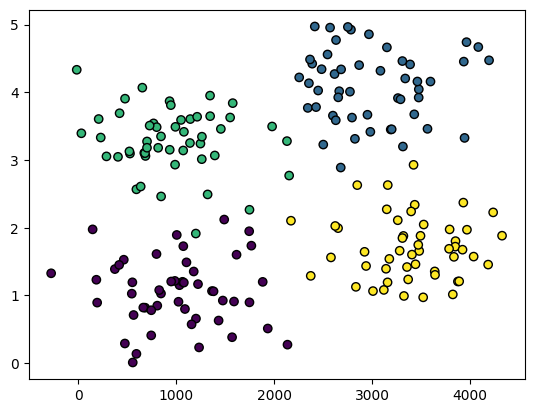

In [2]:
from sklearn.datasets import make_blobs
from sklearn.neural_network import MLPClassifier
blob_centers = ([1, 1], [3, 4], [1, 3.3], [3.5, 1.8])
X, y = make_blobs(n_samples=200, 
                          centers=blob_centers, 
                          cluster_std=0.5,
                          random_state=0)

X[:, 0] *= 1000

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

In [3]:
clf = MLPClassifier(hidden_layer_sizes=(6,), 
                    random_state=1).fit(X, y)

2. Просмотрите параметры модели, визуализируйте и улучшите ее работу.

In [4]:
from sklearn.metrics import confusion_matrix
print("Веса между входным и скрытым слоем:")
print(clf.coefs_[0])
print("\nВеса между скрытым и выходным слоем:")
print(clf.coefs_[1])

Веса между входным и скрытым слоем:
[[-0.09809877  0.33667051 -0.82024119 -0.29720839 -0.56852789 -0.66056109]
 [-0.58903611 -0.31219238 -0.22424296  0.11423652 -0.18324369  0.37321781]]

Веса между скрытым и выходным слоем:
[[-0.51316658 -0.43365467  0.43189995  0.68148414]
 [-0.24370005  0.34328608  0.57835494  0.57889271]
 [-0.59713359 -0.67678056 -0.46609801  0.54011704]
 [-0.5769702  -0.10221922  0.75476969  0.00610289]
 [ 0.34285864 -0.25645017  0.33417991  0.47281254]
 [-0.7006119   0.35515533  0.80295119  0.33880635]]


In [5]:
for i in range(len(clf.coefs_)):
    number_neurons_in_layer = clf.coefs_[i].shape[1]
    for j in range(number_neurons_in_layer):
        weights = clf.coefs_[i][:,j]
        print(i, j, weights, end=", ")
        print()
    print()

0 0 [-0.09809877 -0.58903611], 
0 1 [ 0.33667051 -0.31219238], 
0 2 [-0.82024119 -0.22424296], 
0 3 [-0.29720839  0.11423652], 
0 4 [-0.56852789 -0.18324369], 
0 5 [-0.66056109  0.37321781], 

1 0 [-0.51316658 -0.24370005 -0.59713359 -0.5769702   0.34285864 -0.7006119 ], 
1 1 [-0.43365467  0.34328608 -0.67678056 -0.10221922 -0.25645017  0.35515533], 
1 2 [ 0.43189995  0.57835494 -0.46609801  0.75476969  0.33417991  0.80295119], 
1 3 [0.68148414 0.57889271 0.54011704 0.00610289 0.47281254 0.33880635], 



In [6]:
print("Веса смещения для скрытого слоя:")
print(clf.intercepts_[0])
print("\nВеса смещения для выходного слоя:")
print(clf.intercepts_[1])

Веса смещения для скрытого слоя:
[-0.55752645  0.60978582 -0.8640854   0.33258994 -0.18652436  0.05696655]

Веса смещения для выходного слоя:
[-0.29413473  0.49414359 -0.60792984 -0.11888525]


In [7]:
confusion_matrix(y, clf.predict(X))

array([[ 0,  0,  0, 50],
       [ 0,  0,  0, 50],
       [ 0,  0,  0, 50],
       [ 0,  0,  0, 50]])

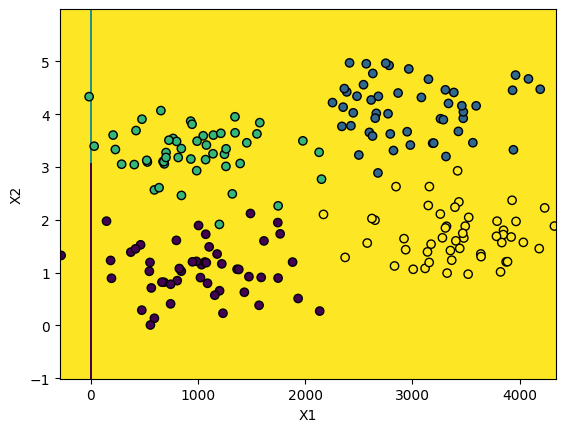

In [8]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
scaler.fit(X)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


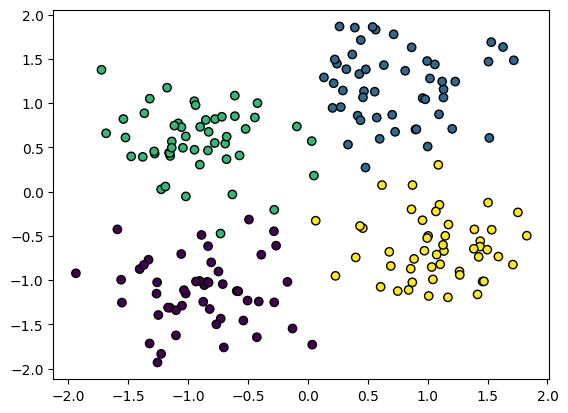

In [10]:
X_scaled = scaler.transform(X)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y,  edgecolors='black',linewidth=1)

In [11]:
clf = MLPClassifier(hidden_layer_sizes=(6,), 
                    random_state=1).fit(X_scaled, y)
confusion_matrix(y, clf.predict(X_scaled))

C:\Users\_System\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


array([[22,  0, 11, 17],
       [ 0, 38,  0, 12],
       [ 0,  3, 45,  2],
       [ 0,  5,  0, 45]])

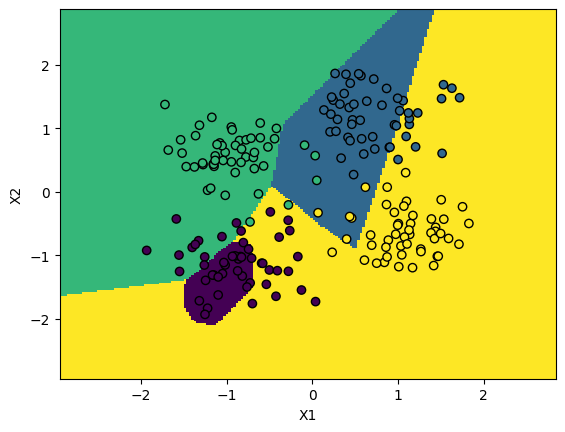

In [12]:
X0 = np.linspace(X_scaled[:, 0].min()-1,X_scaled[:, 0].max()+1, X_scaled.shape[0])
X1 = np.linspace(X_scaled[:, 1].min()-1,X_scaled[:, 1].max()+1, X_scaled.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [13]:
clf = MLPClassifier(hidden_layer_sizes=(6,), max_iter=10_000, verbose=True).fit(X_scaled, y)

Iteration 1, loss = 2.15674465
Iteration 2, loss = 2.14909307
Iteration 3, loss = 2.14147001
Iteration 4, loss = 2.13387602
Iteration 5, loss = 2.12631162
Iteration 6, loss = 2.11877731
Iteration 7, loss = 2.11128412
Iteration 8, loss = 2.10383074
Iteration 9, loss = 2.09640915
Iteration 10, loss = 2.08901948
Iteration 11, loss = 2.08166185
Iteration 12, loss = 2.07433633
Iteration 13, loss = 2.06703954
Iteration 14, loss = 2.05978019
Iteration 15, loss = 2.05256694
Iteration 16, loss = 2.04539906
Iteration 17, loss = 2.03827288
Iteration 18, loss = 2.03117958
Iteration 19, loss = 2.02411964
Iteration 20, loss = 2.01709846
Iteration 21, loss = 2.01011032
Iteration 22, loss = 2.00315396
Iteration 23, loss = 1.99622900
Iteration 24, loss = 1.98933715
Iteration 25, loss = 1.98248930
Iteration 26, loss = 1.97567255
Iteration 27, loss = 1.96888841
Iteration 28, loss = 1.96213584
Iteration 29, loss = 1.95541456
Iteration 30, loss = 1.94872351
Iteration 31, loss = 1.94206237
Iteration 32, los

In [14]:
confusion_matrix(y, clf.predict(X_scaled))

array([[50,  0,  0,  0],
       [ 0, 50,  0,  0],
       [ 2,  0, 48,  0],
       [ 0,  1,  0, 49]])

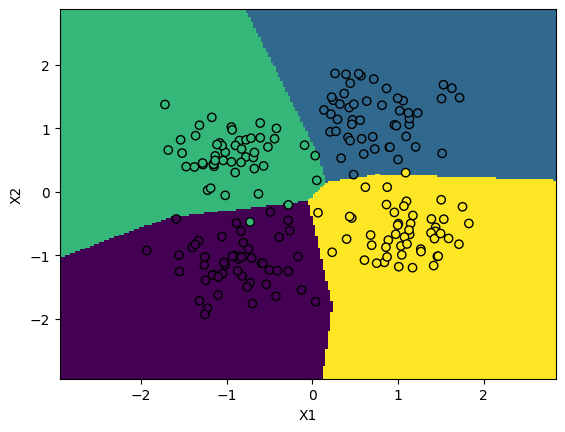

In [15]:
X0 = np.linspace(X_scaled[:, 0].min()-1,X_scaled[:, 0].max()+1, X_scaled.shape[0])
X1 = np.linspace(X_scaled[:, 1].min()-1,X_scaled[:, 1].max()+1, X_scaled.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [16]:
clf = MLPClassifier(hidden_layer_sizes=(100, ), max_iter=10_000).fit(X_scaled, y)
confusion_matrix(y, clf.predict(X_scaled))

array([[50,  0,  0,  0],
       [ 0, 50,  0,  0],
       [ 1,  0, 49,  0],
       [ 0,  0,  0, 50]])

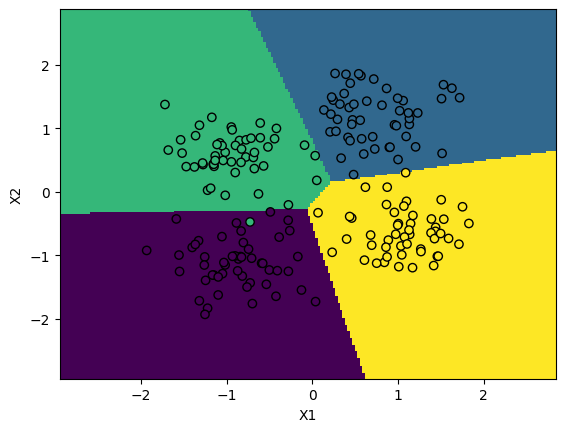

In [17]:
X0 = np.linspace(X_scaled[:, 0].min()-1,X_scaled[:, 0].max()+1, X_scaled.shape[0])
X1 = np.linspace(X_scaled[:, 1].min()-1,X_scaled[:, 1].max()+1, X_scaled.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

# Задания для самостоятельного выполнения

1. Создайте однослойный перцептрон с 1, 2, 10 и 100 нейронами. Сравние их точность и сделайте вывод о достаточном количестве нейронов.

In [18]:
clf = MLPClassifier(hidden_layer_sizes=(1,), max_iter=10_000, verbose=True).fit(X_scaled, y)

Iteration 1, loss = 1.49297790
Iteration 2, loss = 1.49198960
Iteration 3, loss = 1.49100042
Iteration 4, loss = 1.49001036
Iteration 5, loss = 1.48901941
Iteration 6, loss = 1.48802756
Iteration 7, loss = 1.48703071
Iteration 8, loss = 1.48603214
Iteration 9, loss = 1.48502764
Iteration 10, loss = 1.48402190
Iteration 11, loss = 1.48301498
Iteration 12, loss = 1.48200693
Iteration 13, loss = 1.48099777
Iteration 14, loss = 1.47998753
Iteration 15, loss = 1.47897624
Iteration 16, loss = 1.47796389
Iteration 17, loss = 1.47695052
Iteration 18, loss = 1.47593612
Iteration 19, loss = 1.47492071
Iteration 20, loss = 1.47390429
Iteration 21, loss = 1.47288688
Iteration 22, loss = 1.47186846
Iteration 23, loss = 1.47084907
Iteration 24, loss = 1.46982869
Iteration 25, loss = 1.46880733
Iteration 26, loss = 1.46778501
Iteration 27, loss = 1.46676172
Iteration 28, loss = 1.46573747
Iteration 29, loss = 1.46471228
Iteration 30, loss = 1.46368613
Iteration 31, loss = 1.46265905
Iteration 32, los

In [19]:
confusion_matrix(y, clf.predict(X_scaled))

array([[50,  0,  0,  0],
       [ 0, 46,  4,  0],
       [ 2, 20, 24,  4],
       [46,  0,  3,  1]])

In [20]:
clf.score(X_scaled, y)

0.605

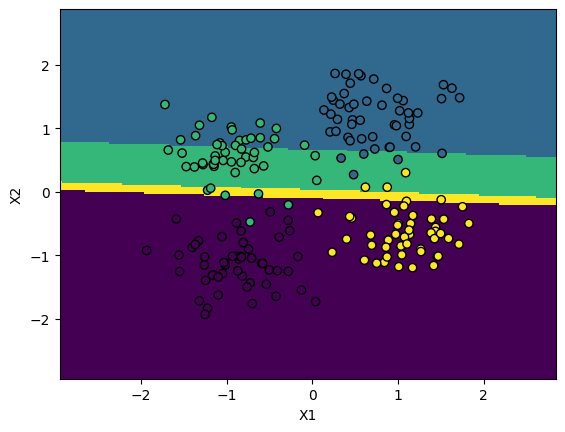

In [21]:
X0 = np.linspace(X_scaled[:, 0].min()-1,X_scaled[:, 0].max()+1, X_scaled.shape[0])
X1 = np.linspace(X_scaled[:, 1].min()-1,X_scaled[:, 1].max()+1, X_scaled.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

Перцептрон с 2мя нейронами

In [22]:
clf = MLPClassifier(hidden_layer_sizes=(2,), max_iter=10_000, verbose=True).fit(X_scaled, y)

Iteration 1, loss = 1.67424467
Iteration 2, loss = 1.67105422
Iteration 3, loss = 1.66787315
Iteration 4, loss = 1.66470163
Iteration 5, loss = 1.66153987
Iteration 6, loss = 1.65838804
Iteration 7, loss = 1.65524634
Iteration 8, loss = 1.65211493
Iteration 9, loss = 1.64899399
Iteration 10, loss = 1.64588368
Iteration 11, loss = 1.64278418
Iteration 12, loss = 1.63969563
Iteration 13, loss = 1.63661819
Iteration 14, loss = 1.63355201
Iteration 15, loss = 1.63049704
Iteration 16, loss = 1.62745285
Iteration 17, loss = 1.62442027
Iteration 18, loss = 1.62139944
Iteration 19, loss = 1.61838951
Iteration 20, loss = 1.61539038
Iteration 21, loss = 1.61240322
Iteration 22, loss = 1.60942814
Iteration 23, loss = 1.60646527
Iteration 24, loss = 1.60351468
Iteration 25, loss = 1.60057647
Iteration 26, loss = 1.59765073
Iteration 27, loss = 1.59473752
Iteration 28, loss = 1.59183691
Iteration 29, loss = 1.58894897
Iteration 30, loss = 1.58607533
Iteration 31, loss = 1.58321475
Iteration 32, los

In [23]:
confusion_matrix(y, clf.predict(X_scaled))

array([[49,  0,  1,  0],
       [ 0, 50,  0,  0],
       [ 2,  0, 48,  0],
       [ 1,  0,  0, 49]])

In [24]:
clf.score(X_scaled, y)

0.98

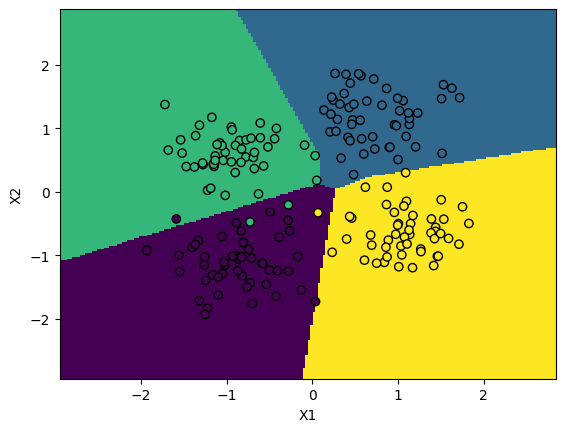

In [25]:
X0 = np.linspace(X_scaled[:, 0].min()-1,X_scaled[:, 0].max()+1, X_scaled.shape[0])
X1 = np.linspace(X_scaled[:, 1].min()-1,X_scaled[:, 1].max()+1, X_scaled.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [26]:
clf = MLPClassifier(hidden_layer_sizes=(10,), max_iter=10_000, verbose=True).fit(X_scaled, y)

Iteration 1, loss = 1.63064000
Iteration 2, loss = 1.62442144
Iteration 3, loss = 1.61822952
Iteration 4, loss = 1.61206565
Iteration 5, loss = 1.60592534
Iteration 6, loss = 1.59981185
Iteration 7, loss = 1.59373760
Iteration 8, loss = 1.58769961
Iteration 9, loss = 1.58169892
Iteration 10, loss = 1.57573142
Iteration 11, loss = 1.56979386
Iteration 12, loss = 1.56388717
Iteration 13, loss = 1.55801035
Iteration 14, loss = 1.55216482
Iteration 15, loss = 1.54635786
Iteration 16, loss = 1.54058197
Iteration 17, loss = 1.53483453
Iteration 18, loss = 1.52912796
Iteration 19, loss = 1.52346703
Iteration 20, loss = 1.51784220
Iteration 21, loss = 1.51226670
Iteration 22, loss = 1.50672335
Iteration 23, loss = 1.50121303
Iteration 24, loss = 1.49573439
Iteration 25, loss = 1.49028692
Iteration 26, loss = 1.48487567
Iteration 27, loss = 1.47949755
Iteration 28, loss = 1.47414787
Iteration 29, loss = 1.46882738
Iteration 30, loss = 1.46353672
Iteration 31, loss = 1.45827658
Iteration 32, los

In [27]:
confusion_matrix(y, clf.predict(X_scaled))

array([[50,  0,  0,  0],
       [ 0, 50,  0,  0],
       [ 1,  1, 48,  0],
       [ 0,  0,  0, 50]])

In [28]:
clf.score(X_scaled, y)

0.99

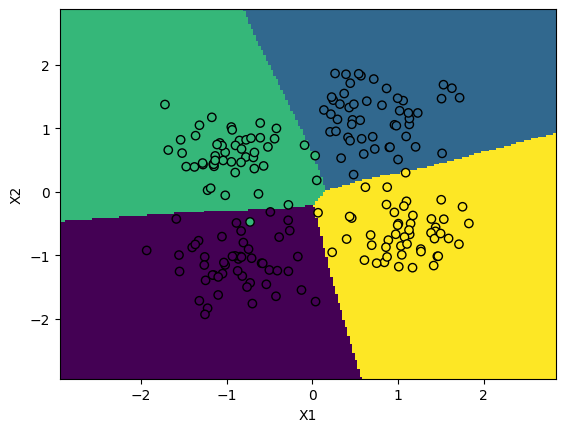

In [29]:
X0 = np.linspace(X_scaled[:, 0].min()-1,X_scaled[:, 0].max()+1, X_scaled.shape[0])
X1 = np.linspace(X_scaled[:, 1].min()-1,X_scaled[:, 1].max()+1, X_scaled.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

5. Постройте и оцените модель классификации с помощью перцептрона на датасете, который вы использовали на контрольной по классификиации (если вы ее не выполняли, возьмите любой датасет из раздела "real world datasets" в библиотеке sklearn).

In [30]:
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)
X_scaled_iris = scaler.fit_transform(X)
clf = MLPClassifier(hidden_layer_sizes=(10, 10, 10), max_iter=10_000, verbose=True).fit(X_scaled_iris, y)

Iteration 1, loss = 1.28113352
Iteration 2, loss = 1.27103182
Iteration 3, loss = 1.26132951
Iteration 4, loss = 1.25178532
Iteration 5, loss = 1.24242512
Iteration 6, loss = 1.23341240
Iteration 7, loss = 1.22471219
Iteration 8, loss = 1.21630500
Iteration 9, loss = 1.20818371
Iteration 10, loss = 1.20039176
Iteration 11, loss = 1.19292896
Iteration 12, loss = 1.18572747
Iteration 13, loss = 1.17880393
Iteration 14, loss = 1.17202326
Iteration 15, loss = 1.16542529
Iteration 16, loss = 1.15903056
Iteration 17, loss = 1.15274211
Iteration 18, loss = 1.14656172
Iteration 19, loss = 1.14047649
Iteration 20, loss = 1.13445349
Iteration 21, loss = 1.12848049
Iteration 22, loss = 1.12255846
Iteration 23, loss = 1.11666304
Iteration 24, loss = 1.11081664
Iteration 25, loss = 1.10498173
Iteration 26, loss = 1.09917335
Iteration 27, loss = 1.09335262
Iteration 28, loss = 1.08754498
Iteration 29, loss = 1.08177783
Iteration 30, loss = 1.07604221
Iteration 31, loss = 1.07032197
Iteration 32, los

In [31]:
confusion_matrix(y, clf.predict(X_scaled_iris))

array([[50,  0,  0],
       [ 0, 49,  1],
       [ 0,  0, 50]])

6. Постройте и оцените модель регрессии с помощью перцептрона на датасете, который вы использовали на контрольной по регрессии.

In [32]:
from sklearn.datasets import load_diabetes
diabets = load_diabetes()
features = diabets.data
data = pd.DataFrame(features, columns = diabets.feature_names)
data.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [33]:
X_diabetes, y_diabetes = diabets.data, diabets.target
X_diabetes.shape

(442, 10)

In [34]:
X_diabetes_scaled = scaler.fit_transform(X_diabetes)
clf = MLPClassifier(hidden_layer_sizes=(12, 12), max_iter=10_000, verbose=True).fit(X_diabetes_scaled, y_diabetes)

Iteration 1, loss = 5.37894022
Iteration 2, loss = 5.37047477
Iteration 3, loss = 5.36361216
Iteration 4, loss = 5.35719375
Iteration 5, loss = 5.35079730
Iteration 6, loss = 5.34446101
Iteration 7, loss = 5.33809042
Iteration 8, loss = 5.33180437
Iteration 9, loss = 5.32543202
Iteration 10, loss = 5.31908227
Iteration 11, loss = 5.31249609
Iteration 12, loss = 5.30599482
Iteration 13, loss = 5.29899268
Iteration 14, loss = 5.29208351
Iteration 15, loss = 5.28482574
Iteration 16, loss = 5.27755343
Iteration 17, loss = 5.27023400
Iteration 18, loss = 5.26235606
Iteration 19, loss = 5.25433224
Iteration 20, loss = 5.24587480
Iteration 21, loss = 5.23746054
Iteration 22, loss = 5.22865060
Iteration 23, loss = 5.21958154
Iteration 24, loss = 5.21009863
Iteration 25, loss = 5.20067184
Iteration 26, loss = 5.19085400
Iteration 27, loss = 5.18048458
Iteration 28, loss = 5.17047997
Iteration 29, loss = 5.15955425
Iteration 30, loss = 5.14891189
Iteration 31, loss = 5.13807098
Iteration 32, los

In [35]:
confusion_matrix(y_diabetes, clf.predict(X_diabetes_scaled))

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 1]], shape=(214, 214))

In [36]:
clf.score(X_diabetes_scaled, y_diabetes)

0.8167420814479638